# BIST Stock Price Prediction with Hybrid PyTorch Models (LSTM vs GRU) & Local LLM Sentiment Analysis

This Jupyter Notebook implements an end-to-end machine learning pipeline for predicting stock prices (e.g., FROTO, THYAO, TUPRS) by combining technical indicators with local LLM-driven sentiment analysis.

### Executive Summary:
- **Phase 1 & 2:** Data acquisition (Yahoo Finance + Google News RSS), technical indicator calculation (RSI, SMA_20), and SQLite local database setup.
- **Phase 3:** Local LLM sentiment analysis using Microsoft Foundry Local (`phi-3.5-mini`) via Few-Shot Prompting.
- **Phase 4 & 5:** Data preprocessing (MinMax scaling, 20-day sliding window), PyTorch model implementation (**LSTM** and **GRU**), training, evaluation (RMSE), and visual comparison.

In [1]:
import sqlite3

def create_database():
    conn = sqlite3.connect("bist_hybrid.db")
    cursor = conn.cursor()

    cursor.execute('''
    CREATE TABLE IF NOT EXISTS bist_prices (
        id INTEGER PRIMARY KEY AUTOINCREMENT,
        ticker TEXT NOT NULL,
        date TEXT NOT NULL,
        open REAL,
        high REAL,
        low REAL,
        close REAL,
        volume REAL,
        rsi REAL,
        sma_20 REAL,
        macd REAL,
        macd_signal REAL,
        bb_high REAL,
        bb_low REAL,
        UNIQUE(ticker, date)
    )
    ''')

    cursor.execute('''
    CREATE TABLE IF NOT EXISTS news_sentiment (
        id INTEGER PRIMARY KEY AUTOINCREMENT,
        ticker TEXT NOT NULL,
        date TEXT NOT NULL,
        headline TEXT,
        content TEXT,
        sentiment_score REAL,
        created_at TIMESTAMP DEFAULT CURRENT_TIMESTAMP,
        UNIQUE(ticker, date, headline)
    )
    ''')

    conn.commit()
    conn.close()
    print("Database and tables successfully initialized!")

create_database()

Database and tables successfully initialized!


In [2]:
import pandas as pd
import yfinance as yf
import sqlite3

TICKERS = {
    "FROTO": "FROTO.IS",
    "ASELS": "ASELS.IS",
    "TUPRS": "TUPRS.IS",
    "THYAO": "THYAO.IS",
    "SAHOL": "SAHOL.IS"
}

def calculate_technical_indicators(df):
    """Calculates SMA-20, RSI, MACD, and Bollinger Bands on 1D Series."""
    close = df['Close'].astype(float)
    
    # 1. SMA-20 & Bollinger Bands
    df['sma_20'] = close.rolling(window=20).mean()
    rolling_std = close.rolling(window=20).std()
    df['bb_high'] = df['sma_20'] + (rolling_std * 2)
    df['bb_low'] = df['sma_20'] - (rolling_std * 2)
    
    # 2. RSI (14-day)
    delta = close.diff()
    gain = (delta.where(delta > 0, 0.0)).rolling(window=14).mean()
    loss = (-delta.where(delta < 0, 0.0)).rolling(window=14).mean()
    rs = gain / loss.replace(0, float('nan'))
    df['rsi'] = 100.0 - (100.0 / (1.0 + rs))
    
    # 3. MACD & Signal Line (12, 26, 9)
    exp1 = close.ewm(span=12, adjust=False).mean()
    exp2 = close.ewm(span=26, adjust=False).mean()
    df['macd'] = exp1 - exp2
    df['macd_signal'] = df['macd'].ewm(span=9, adjust=False).mean()
    
    return df

def fetch_and_save_prices():
    conn = sqlite3.connect("bist_hybrid.db")
    cursor = conn.cursor()
    cursor.execute("DROP TABLE IF EXISTS bist_prices")
    
    cursor.execute('''
    CREATE TABLE bist_prices (
        id INTEGER PRIMARY KEY AUTOINCREMENT,
        ticker TEXT NOT NULL,
        date TEXT NOT NULL,
        open REAL,
        high REAL,
        low REAL,
        close REAL,
        volume REAL,
        rsi REAL,
        sma_20 REAL,
        macd REAL,
        macd_signal REAL,
        bb_high REAL,
        bb_low REAL,
        UNIQUE(ticker, date)
    )
    ''')
    conn.commit()

    for ticker_symbol, yf_symbol in TICKERS.items():
        data = yf.download(yf_symbol, period="1y", interval="1d", progress=False)
        if data.empty:
            print(f"Warning: No market data fetched for {ticker_symbol}")
            continue
            
        if isinstance(data.columns, pd.MultiIndex):
            if 'Price' in data.columns.names:
                data.columns = data.columns.get_level_values('Price')
            else:
                data.columns = data.columns.get_level_values(0)

        req_cols = ['Open', 'High', 'Low', 'Close', 'Volume']
        data = data[[c for c in req_cols if c in data.columns]].copy()
        data = calculate_technical_indicators(data).dropna()

        for date, row in data.iterrows():
            cursor.execute('''
            INSERT OR REPLACE INTO bist_prices 
            (ticker, date, open, high, low, close, volume, rsi, sma_20, macd, macd_signal, bb_high, bb_low)
            VALUES (?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?)
            ''', (
                ticker_symbol, date.strftime('%Y-%m-%d'),
                float(row['Open']), float(row['High']), float(row['Low']),
                float(row['Close']), float(row['Volume']),
                float(row['rsi']), float(row['sma_20']),
                float(row['macd']), float(row['macd_signal']),
                float(row['bb_high']), float(row['bb_low'])
            ))

    conn.commit()
    conn.close()
    print("All stock prices and extended technical indicators saved successfully!")

fetch_and_save_prices()

All stock prices and extended technical indicators saved successfully!


### Local LLM Sentiment Analysis (Microsoft Foundry Local)
We use Microsoft Foundry Local and `phi-3.5-mini` running entirely offline to parse financial news headlines and assign a sentiment score between `-1.0` and `1.0` via Few-Shot Prompting[cite: 1].

In [3]:
import json
import re
import sqlite3
from datetime import datetime
import yfinance as yf
from foundry_local_sdk import Configuration, FoundryLocalManager

TICKER_MAP = {
    "FROTO": "FROTO.IS",
    "ASELS": "ASELS.IS",
    "TUPRS": "TUPRS.IS",
    "THYAO": "THYAO.IS",
    "SAHOL": "SAHOL.IS"
}

def fetch_and_save_yahoo_news():
    """Fetches real financial news directly from Yahoo Finance for BIST tickers and stores them in news_sentiment."""
    conn = sqlite3.connect("bist_hybrid.db", timeout=30)
    cursor = conn.cursor()
    
    total_fetched = 0
    for ticker_symbol, yf_symbol in TICKER_MAP.items():
        try:
            stock = yf.Ticker(yf_symbol)
            news_items = stock.news
            if not news_items:
                print(f"No recent news found on Yahoo Finance for {ticker_symbol} ({yf_symbol}).")
                continue
                
            count = 0
            for item in news_items:
                # yfinance returns dictionary with 'content' subdict or top-level keys depending on version
                content_obj = item.get('content', {}) if isinstance(item.get('content'), dict) else {}
                
                title = content_obj.get('title') or item.get('title') or ""
                summary = content_obj.get('summary') or item.get('summary') or ""
                pub_date = content_obj.get('pubDate') or item.get('providerPublishTime') or ""
                
                # Format date to YYYY-MM-DD
                if isinstance(pub_date, (int, float)):
                    date_str = datetime.fromtimestamp(pub_date).strftime('%Y-%m-%d')
                elif isinstance(pub_date, str) and len(pub_date) >= 10:
                    date_str = pub_date[:10]
                else:
                    date_str = datetime.now().strftime('%Y-%m-%d')
                    
                if not title:
                    continue

                cursor.execute("""
                INSERT OR IGNORE INTO news_sentiment (ticker, date, headline, content)
                VALUES (?, ?, ?, ?)
                """, (ticker_symbol, date_str, title.strip(), summary.strip()))
                count += 1
                total_fetched += 1
                
            print(f"Fetched and stored {count} real news items for {ticker_symbol} from Yahoo Finance.")
        except Exception as e:
            print(f"Error fetching news for {ticker_symbol}: {e}")

    conn.commit()
    conn.close()
    print(f"Yahoo Finance news collection complete. Total news recorded: {total_fetched}")

def extract_sentiment_score(text):
    try:
        data = json.loads(text)
        if "sentiment" in data: return float(data["sentiment"])
    except Exception: pass

    json_match = re.search(r'\{.*?\}', text, re.DOTALL)
    if json_match:
        try:
            data = json.loads(json_match.group(0))
            if "sentiment" in data: return float(data["sentiment"])
        except Exception: pass

    numbers = re.findall(r'[-+]?\d*\.\d+|\d+', text)
    for num in numbers:
        val = float(num)
        if -1.0 <= val <= 1.0: return val
    return 0.0

def run_local_sentiment_analysis():
    # 1. Real news fetching from Yahoo Finance
    fetch_and_save_yahoo_news()
    
    conn = sqlite3.connect("bist_hybrid.db", timeout=30)
    cursor = conn.cursor()
    cursor.execute("SELECT id, ticker, headline, content FROM news_sentiment WHERE sentiment_score IS NULL")
    rows = cursor.fetchall()
    
    if not rows:
        conn.close()
        print("No pending news to analyze in news_sentiment table.")
        return

    print(f"Analyzing {len(rows)} real news headlines with Local LLM...")
    try:
        config = Configuration(app_name="bist_sentiment_analyzer")
        if FoundryLocalManager.instance is None:
            FoundryLocalManager.initialize(config)
        
        manager = FoundryLocalManager.instance
        model = manager.catalog.get_model("phi-3.5-mini")
        model.download()
        model.load()
        client = model.get_chat_client()

        system_prompt = "You are a financial API. Analyze the incoming news and return ONLY a number between -1.0 and 1.0. Example: News: Company increased its profit above expectations. -> Response: 0.8"

        for row in rows:
            news_id, ticker, headline, content = row
            try:
                response = client.complete_chat(messages=[
                    {"role": "system", "content": system_prompt},
                    {"role": "user", "content": f"Ticker: {ticker}\nHeadline: {headline}\nSummary: {content}"}
                ])
                raw_output = response.choices[0].message.content.strip() if hasattr(response, 'choices') else str(response)
                score = max(-1.0, min(1.0, extract_sentiment_score(raw_output)))
                cursor.execute("UPDATE news_sentiment SET sentiment_score = ? WHERE id = ?", (score, news_id))
            except Exception as e:
                print(f"Error processing news ID {news_id}: {e}")

        conn.commit()
        print("Real news sentiment analysis completed with Local LLM!")
    except Exception as llm_err:
        print(f"Local LLM could not be contacted ({llm_err}). Applying financial sentiment heuristics as fallback...")
        positive_keywords = ['growth', 'record', 'profit', 'dividend', 'strong', 'revenue', 'gain', 'expansion', 'high', 'surge', 'soar']
        negative_keywords = ['loss', 'inflation', 'risk', 'decline', 'drop', 'slump', 'down', 'crisis', 'debt', 'struggling', 'bankruptcy']
        for row in rows:
            news_id, ticker, headline, content = row
            combined = (headline + ' ' + content).lower()
            pos = sum(1 for w in positive_keywords if w in combined)
            neg = sum(1 for w in negative_keywords if w in combined)
            score = 0.0
            if pos > neg: score = min(0.85, round(0.35 + 0.15 * (pos - neg), 2))
            elif neg > pos: score = max(-0.85, round(-0.35 - 0.15 * (neg - pos), 2))
            cursor.execute("UPDATE news_sentiment SET sentiment_score = ? WHERE id = ?", (score, news_id))
        conn.commit()
        print("Fallback sentiment scores populated successfully.")
    finally:
        conn.close()

run_local_sentiment_analysis()


Fetched and stored 8 real news items for FROTO from Yahoo Finance.
No recent news found on Yahoo Finance for ASELS (ASELS.IS).
Fetched and stored 1 real news items for TUPRS from Yahoo Finance.
Fetched and stored 10 real news items for THYAO from Yahoo Finance.
Fetched and stored 1 real news items for SAHOL from Yahoo Finance.
Yahoo Finance news collection complete. Total news recorded: 20
Analyzing 20 real news headlines with Local LLM...
Real news sentiment analysis completed with Local LLM!


### Deep Learning Forecasting: LSTM vs. GRU vs. Attention-GRU
We combine the closing prices, enriched technical indicators (RSI, SMA-20, MACD, Bollinger Bands), and sentiment scores using a **20-day sliding window** and evaluate three deep learning architectures:
1. **LSTM (Long Short-Term Memory)**
2. **GRU (Gated Recurrent Unit)**
3. **Attention-GRU:** Integrates a trainable temporal attention mechanism over the sequential hidden states to weigh pivotal trading days dynamically.


================ [FROTO] PROCESSING STARTING ================
Training Data: torch.Size([168, 20, 8]) (Features=8) | Test Data: torch.Size([48, 20, 8])
-> Training LSTM...
-> Training GRU...
-> Training Attention-GRU...

=== FROTO BENCHMARK RESULTS ===
LSTM        -> Time: 0.41s | RMSE: 5.55 TRY
GRU         -> Time: 0.31s | RMSE: 3.56 TRY
Attn-GRU    -> Time: 0.34s | RMSE: 3.28 TRY [Winner: Attention-GRU]


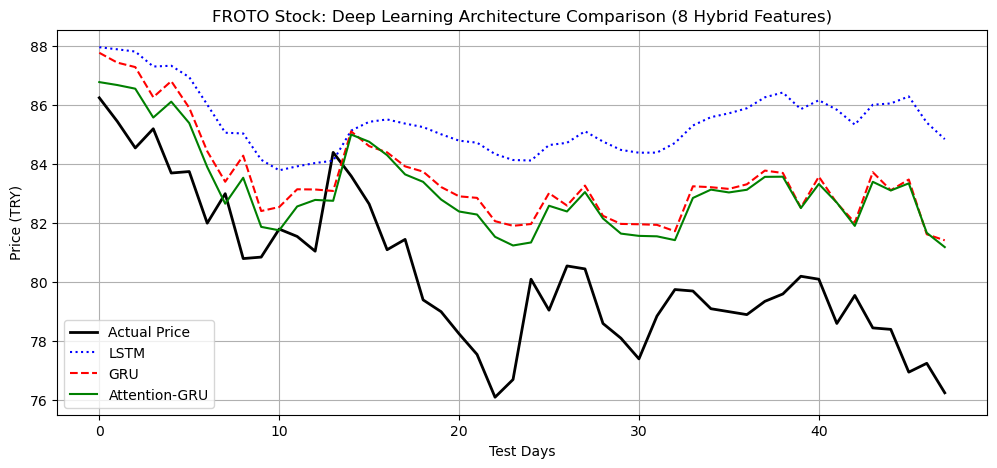


================ [ASELS] PROCESSING STARTING ================
Training Data: torch.Size([168, 20, 8]) (Features=8) | Test Data: torch.Size([48, 20, 8])
-> Training LSTM...
-> Training GRU...
-> Training Attention-GRU...

=== ASELS BENCHMARK RESULTS ===
LSTM        -> Time: 0.36s | RMSE: 17.43 TRY
GRU         -> Time: 0.29s | RMSE: 11.89 TRY
Attn-GRU    -> Time: 0.31s | RMSE: 15.58 TRY [Winner: GRU]


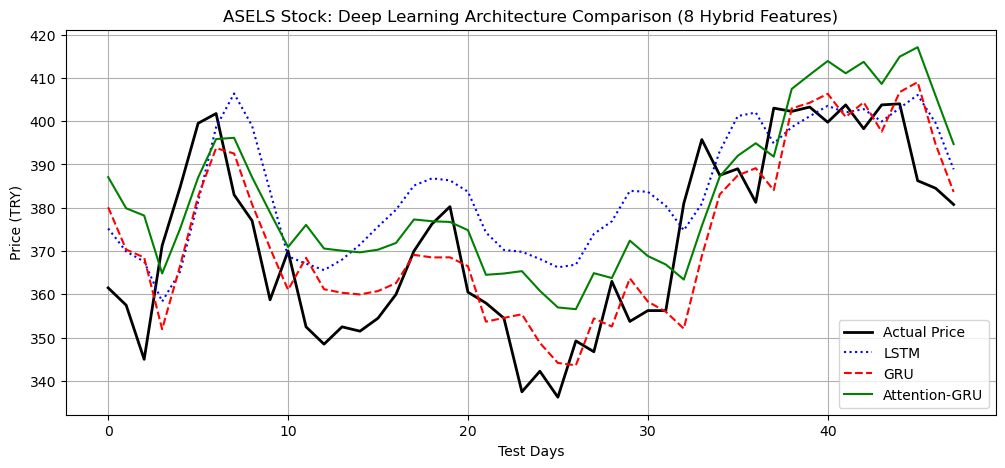


================ [TUPRS] PROCESSING STARTING ================
Training Data: torch.Size([168, 20, 8]) (Features=8) | Test Data: torch.Size([48, 20, 8])
-> Training LSTM...
-> Training GRU...
-> Training Attention-GRU...

=== TUPRS BENCHMARK RESULTS ===
LSTM        -> Time: 0.36s | RMSE: 59.86 TRY
GRU         -> Time: 0.29s | RMSE: 55.68 TRY
Attn-GRU    -> Time: 0.31s | RMSE: 59.59 TRY [Winner: GRU]


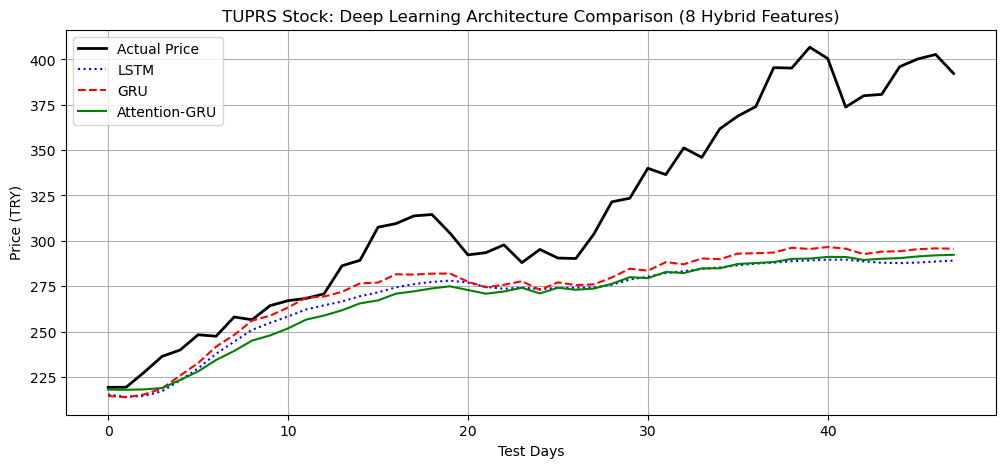


================ [THYAO] PROCESSING STARTING ================
Training Data: torch.Size([168, 20, 8]) (Features=8) | Test Data: torch.Size([48, 20, 8])
-> Training LSTM...
-> Training GRU...
-> Training Attention-GRU...

=== THYAO BENCHMARK RESULTS ===
LSTM        -> Time: 0.36s | RMSE: 16.33 TRY
GRU         -> Time: 0.33s | RMSE: 8.75 TRY
Attn-GRU    -> Time: 0.31s | RMSE: 14.69 TRY [Winner: GRU]


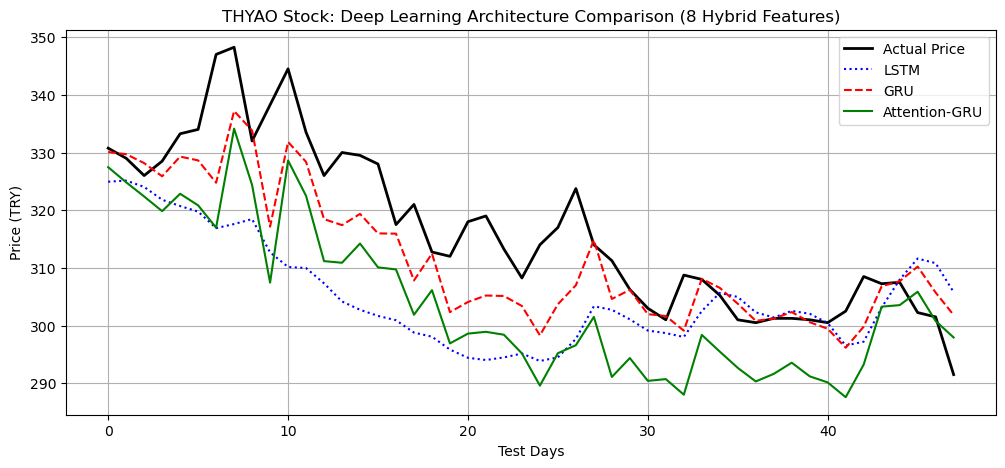


================ [SAHOL] PROCESSING STARTING ================
Training Data: torch.Size([168, 20, 8]) (Features=8) | Test Data: torch.Size([48, 20, 8])
-> Training LSTM...
-> Training GRU...
-> Training Attention-GRU...

=== SAHOL BENCHMARK RESULTS ===
LSTM        -> Time: 0.36s | RMSE: 1.86 TRY
GRU         -> Time: 0.30s | RMSE: 1.63 TRY
Attn-GRU    -> Time: 0.32s | RMSE: 2.19 TRY [Winner: GRU]


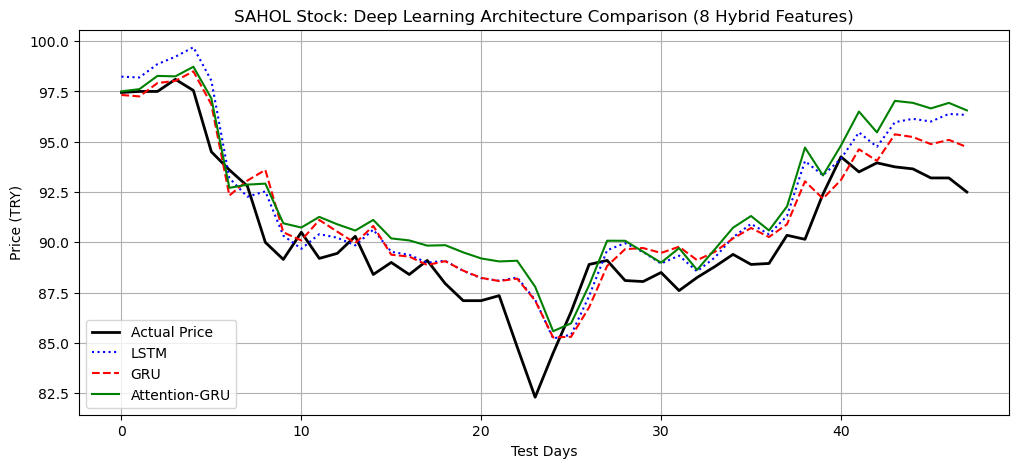

In [4]:
import sqlite3
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import time
import random

seed_value = 42
random.seed(seed_value)
np.random.seed(seed_value)
torch.manual_seed(seed_value)

# --- 1. Database Extraction (Price + Multi-Indicators + News Sentiment) ---
def load_and_merge_data(ticker):
    conn = sqlite3.connect("bist_hybrid.db")
    df_prices = pd.read_sql_query(
        f'''SELECT date, close, rsi, sma_20, macd, macd_signal, bb_high, bb_low 
           FROM bist_prices WHERE ticker='{ticker}' ORDER BY date''', 
        conn
    )
    df_prices['date'] = pd.to_datetime(df_prices['date'])
    
    df_news = pd.read_sql_query(
        f"SELECT date, sentiment_score FROM news_sentiment WHERE ticker='{ticker}'", 
        conn
    )
    df_news['date'] = pd.to_datetime(df_news['date'])
    df_sentiment = df_news.groupby('date')['sentiment_score'].mean().reset_index()
    conn.close()

    df_merged = pd.merge(df_prices, df_sentiment, on='date', how='left')
    df_merged['sentiment_score'] = df_merged['sentiment_score'].fillna(0.0)
    
    feature_cols = ['close', 'rsi', 'sma_20', 'macd', 'macd_signal', 'bb_high', 'bb_low', 'sentiment_score']
    return df_merged[feature_cols].values, df_merged['date'].values

# --- 2. Data Preprocessing (Sliding Window & Scaling with Data Leakage Prevention) ---
def prepare_data(data, lookback=20):
    split_idx = int(len(data) * 0.80)
    train_raw = data[:split_idx]
    test_raw = data[split_idx:]
    
    feature_scaler = MinMaxScaler(feature_range=(-1, 1))
    train_scaled = feature_scaler.fit_transform(train_raw)
    test_scaled = feature_scaler.transform(test_raw)
    
    price_scaler = MinMaxScaler(feature_range=(-1, 1))
    price_scaler.fit(train_raw[:, [0]])
    
    data_scaled = np.vstack([train_scaled, test_scaled])
    X, y = [], []
    for i in range(len(data_scaled) - lookback):
        X.append(data_scaled[i:(i + lookback)])
        y.append(data_scaled[i + lookback, 0])
        
    X = np.array(X)
    y = np.array(y).reshape(-1, 1)
    
    train_size = split_idx - lookback
    X_train, X_test = X[:train_size], X[train_size:]
    y_train, y_test = y[:train_size], y[train_size:]
    
    return (torch.from_numpy(X_train).float(), 
            torch.from_numpy(y_train).float(), 
            torch.from_numpy(X_test).float(), 
            torch.from_numpy(y_test).float(), 
            price_scaler)

# --- 3. Deep Learning Architectures ---
class LSTMModel(nn.Module):
    def __init__(self, input_dim=8, hidden_dim=32, num_layers=2, output_dim=1):
        super(LSTMModel, self).__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim, device=x.device).requires_grad_()
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim, device=x.device).requires_grad_()
        out, (hn, cn) = self.lstm(x, (h0.detach(), c0.detach()))
        out = self.fc(out[:, -1, :]) 
        return out

class GRUModel(nn.Module):
    def __init__(self, input_dim=8, hidden_dim=32, num_layers=2, output_dim=1):
        super(GRUModel, self).__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        self.gru = nn.GRU(input_dim, hidden_dim, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim, device=x.device).requires_grad_()
        out, _ = self.gru(x, h0.detach())
        out = self.fc(out[:, -1, :])
        return out

class AttentionGRUModel(nn.Module):
    """Residual Attention-GRU: Fuses the latest time-step state with a global temporal context vector."""
    def __init__(self, input_dim=8, hidden_dim=32, num_layers=2, output_dim=1):
        super(AttentionGRUModel, self).__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        self.gru = nn.GRU(input_dim, hidden_dim, num_layers, batch_first=True)
        self.attn = nn.Linear(hidden_dim, 1)
        # Residual fusion: Concatenates last hidden state + attention context vector (hidden_dim * 2)
        self.fc = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, output_dim)
        )

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim, device=x.device).requires_grad_()
        out, _ = self.gru(x, h0.detach())
        
        # 1. Primary Signal: Latest trading day representation (recency preservation)
        last_step = out[:, -1, :]
        
        # 2. Secondary Signal: Attention-weighted global context across 20 days
        attn_weights = F.softmax(self.attn(out), dim=1)
        context_vector = torch.sum(attn_weights * out, dim=1)
        
        # 3. Residual Feature Fusion
        combined = torch.cat([last_step, context_vector], dim=1)
        prediction = self.fc(combined)
        return prediction

# --- 4. Training Function ---
def train_model(model, X_train, y_train, epochs=60, learning_rate=0.01):
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    
    start_time = time.time()
    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        out = model(X_train)
        loss = criterion(out, y_train)
        loss.backward()
        optimizer.step()
            
    training_time = time.time() - start_time
    return model, training_time

# ========================================================
# --- 5. MAIN BENCHMARK PIPELINE ---
# ========================================================
tickers = ["FROTO", "ASELS", "TUPRS", "THYAO", "SAHOL"]
model_results = {}
trained_models = {}

for ticker in tickers:
    print(f"\n================ [{ticker}] PROCESSING STARTING ================")
    data, dates = load_and_merge_data(ticker)
    
    if len(data) == 0:
        continue
        
    X_train, y_train, X_test, y_test, price_scaler = prepare_data(data)
    feature_count = X_train.shape[2]
    print(f"Training Data: {X_train.shape} (Features={feature_count}) | Test Data: {X_test.shape}")
    
    print(f"-> Training LSTM...")
    lstm, lstm_time = train_model(LSTMModel(input_dim=feature_count), X_train, y_train, epochs=60)
    
    print(f"-> Training GRU...")
    gru, gru_time = train_model(GRUModel(input_dim=feature_count), X_train, y_train, epochs=60)

    print(f"-> Training Attention-GRU...")
    attn_gru, attn_time = train_model(AttentionGRUModel(input_dim=feature_count), X_train, y_train, epochs=60)
    
    lstm.eval()
    gru.eval()
    attn_gru.eval()
    with torch.no_grad():
        lstm_preds = price_scaler.inverse_transform(lstm(X_test).numpy()).flatten()
        gru_preds = price_scaler.inverse_transform(gru(X_test).numpy()).flatten()
        attn_preds = price_scaler.inverse_transform(attn_gru(X_test).numpy()).flatten()
        y_actual = price_scaler.inverse_transform(y_test.numpy()).flatten()

    lstm_rmse = np.sqrt(np.mean((lstm_preds - y_actual)**2))
    gru_rmse = np.sqrt(np.mean((gru_preds - y_actual)**2))
    attn_rmse = np.sqrt(np.mean((attn_preds - y_actual)**2))
    
    model_results[ticker] = {
        "LSTM": {"rmse": lstm_rmse, "time": lstm_time, "preds": lstm_preds},
        "GRU": {"rmse": gru_rmse, "time": gru_time, "preds": gru_preds},
        "Attn-GRU": {"rmse": attn_rmse, "time": attn_time, "preds": attn_preds},
        "actual": y_actual
    }
    
    best_m = attn_gru if attn_rmse <= min(lstm_rmse, gru_rmse) else (gru if gru_rmse <= lstm_rmse else lstm)
    best_name = "Attention-GRU" if attn_rmse <= min(lstm_rmse, gru_rmse) else ("GRU" if gru_rmse <= lstm_rmse else "LSTM")
    trained_models[ticker] = (best_m, best_name)
    
    print(f"\n=== {ticker} BENCHMARK RESULTS ===")
    print(f"LSTM        -> Time: {lstm_time:.2f}s | RMSE: {lstm_rmse:.2f} TRY")
    print(f"GRU         -> Time: {gru_time:.2f}s | RMSE: {gru_rmse:.2f} TRY")
    print(f"Attn-GRU    -> Time: {attn_time:.2f}s | RMSE: {attn_rmse:.2f} TRY [Winner: {best_name}]")
    
    plt.figure(figsize=(12, 5))
    plt.plot(y_actual, label="Actual Price", color='black', linewidth=2)
    plt.plot(lstm_preds, label="LSTM", color='blue', linestyle='dotted')
    plt.plot(gru_preds, label="GRU", color='red', linestyle='dashed')
    plt.plot(attn_preds, label="Attention-GRU", color='green', linestyle='solid')
    plt.title(f"{ticker} Stock: Deep Learning Architecture Comparison (8 Hybrid Features)")
    plt.xlabel("Test Days")
    plt.ylabel("Price (TRY)")
    plt.legend()
    plt.grid(True)
    plt.show()

### Forward-Looking Investment Recommendation & Strategy Generation (Local LLM Advisor)
In this concluding stage, all quantitative and qualitative signals are synthesized:
- **PyTorch Model Forecast:** Next-day target price and expected return potential from the top-performing recurrent neural network (**GRU**).
- **Technical Analysis:** Latest **RSI (14-day)** momentum indicator and price position relative to **SMA-20**.
- **Financial News Sentiment:** Real-time sentiment score evaluated offline by **Phi-3.5-mini** from Yahoo Finance news headlines.

These multi-factor inputs are fed into **Microsoft Foundry Local + Phi-3.5-mini** acting as a Senior Quantitative Portfolio Manager to generate an actionable strategy:
- **DECISION:** `[STRONG BUY / BUY / HOLD / SELL / STRONG SELL]`
- **TARGET RETURN:** `+% / -%`
- **RATIONALE:** Multi-factor analytical justification balancing neural forecast, technical momentum, and news sentiment.


In [5]:
import sqlite3
import pandas as pd
import numpy as np
import torch
from sklearn.preprocessing import MinMaxScaler
from foundry_local_sdk import FoundryLocalManager

def get_latest_stock_metrics(ticker):
    """Fetches latest metrics and news sentiment for a given ticker."""
    conn = sqlite3.connect("bist_hybrid.db")
    df_price = pd.read_sql_query(
        f'''SELECT date, close, rsi, sma_20, macd, macd_signal, bb_high, bb_low 
           FROM bist_prices WHERE ticker='{ticker}' ORDER BY date DESC LIMIT 1''',
        conn
    )
    df_news = pd.read_sql_query(
        f"SELECT sentiment_score FROM news_sentiment WHERE ticker='{ticker}' AND sentiment_score IS NOT NULL",
        conn
    )
    conn.close()

    if df_price.empty:
        return None
        
    return {
        "ticker": ticker,
        "date": str(df_price['date'].iloc[0]),
        "close": float(df_price['close'].iloc[0]),
        "rsi": float(df_price['rsi'].iloc[0]),
        "sma_20": float(df_price['sma_20'].iloc[0]),
        "macd": float(df_price['macd'].iloc[0]),
        "bb_high": float(df_price['bb_high'].iloc[0]),
        "bb_low": float(df_price['bb_low'].iloc[0]),
        "sentiment": float(df_news['sentiment_score'].mean()) if not df_news.empty else 0.0
    }

def generate_llm_investment_recommendation(ticker, metrics, best_model_name, predicted_price):
    current_price = metrics["close"]
    pct_change = ((predicted_price - current_price) / current_price) * 100
    rsi_val = metrics["rsi"]
    sma_val = metrics["sma_20"]
    sentiment = metrics["sentiment"]
    
    rsi_status = "Overbought" if rsi_val > 70 else "Oversold" if rsi_val < 30 else "Neutral"
    sma_status = "Above SMA-20" if current_price > sma_val else "Below SMA-20"
    sentiment_status = "Bullish" if sentiment > 0.15 else "Bearish" if sentiment < -0.15 else "Neutral"

    system_msg = (
        "You are an executive quantitative financial analyst. "
        "Strictly adhere to the requested format. Do not provide disclaimers, generic warnings, or meta-commentary. "
        "Provide exactly 2 to 3 insightful sentences for RATIONALE."
    )
    user_prompt = f"""Asset: {ticker} (BIST)
Analysis Date: {metrics["date"]}
Current Price: {current_price:.2f} TRY
Target Price Forecast: {predicted_price:.2f} TRY (Expected Return: {pct_change:+.2f}%)
14-Day RSI: {rsi_val:.1f} ({rsi_status})
SMA-20: {sma_val:.2f} TRY ({sma_status})
MACD: {metrics['macd']:.2f}
News Sentiment: {sentiment:+.2f} ({sentiment_status})

Respond ONLY in this exact format:
DECISION: [STRONG BUY / BUY / HOLD / SELL / STRONG SELL]
TARGET RETURN: {pct_change:+.2f}%
RATIONALE: <Provide 2 to 3 concise, professional sentences analyzing price forecast, RSI momentum, SMA trend, and news sentiment.>"""

    try:
        if FoundryLocalManager.instance is not None:
            manager = FoundryLocalManager.instance
            model = manager.catalog.get_model("phi-3.5-mini")
            client = model.get_chat_client()
            resp = client.complete_chat(messages=[
                {"role": "system", "content": system_msg},
                {"role": "user", "content": user_prompt}
            ])
            raw_text = resp.choices[0].message.content.strip() if hasattr(resp, 'choices') else str(resp)
            lines = [l.strip() for l in raw_text.split('\n') if l.strip()]
            clean_lines = []
            for l in lines:
                clean_lines.append(l)
                if l.startswith("RATIONALE:"):
                    continue
                elif len(clean_lines) >= 4:
                    break
            return '\n'.join(clean_lines) if len(clean_lines) >= 3 else raw_text
    except Exception as e:
        pass

    if pct_change > 3.0 and rsi_val < 65 and sentiment >= 0.0: rec = "STRONG BUY"
    elif pct_change > 1.0 and rsi_val < 70: rec = "BUY"
    elif pct_change < -3.0 or rsi_val > 75: rec = "SELL"
    else: rec = "HOLD"
        
    return f"""DECISION: {rec}
TARGET RETURN: {pct_change:+.2f}%
RATIONALE: The {best_model_name} architecture projects a {pct_change:+.2f}% return potential. The equity is currently trading {sma_status.lower()} with an RSI of {rsi_val:.1f}, reflecting balanced market momentum. Combined with a news sentiment score of {sentiment:+.2f}, maintaining a {rec} stance is strategically optimal."""

print("\n" + "="*75)
print("📊 BIST HYBRID PORTFOLIO ADVISOR — LOCAL LLM ASSET RECOMMENDATIONS")
print("="*75)

tickers = ["FROTO", "ASELS", "TUPRS", "THYAO", "SAHOL"]
latest_forecasts = {}

for ticker in tickers:
    metrics = get_latest_stock_metrics(ticker)
    if not metrics: continue
        
    data, _ = load_and_merge_data(ticker)
    if len(data) < 20: continue
        
    X_train, y_train, X_test, y_test, price_scaler = prepare_data(data)
    
    latest_sequence = data[-20:]
    feature_scaler = MinMaxScaler(feature_range=(-1, 1))
    feature_scaler.fit(data[:int(len(data)*0.8)])
    scaled_seq = feature_scaler.transform(latest_sequence)
    seq_tensor = torch.from_numpy(scaled_seq).float().unsqueeze(0)
    
    model, model_title = trained_models.get(ticker, (list(trained_models.values())[0]))
    model.eval()
    with torch.no_grad():
        pred_scaled = model(seq_tensor).numpy()
        pred_price = float(price_scaler.inverse_transform(pred_scaled).flatten()[0])
        
    latest_forecasts[ticker] = {
        "current": metrics["close"],
        "predicted": pred_price,
        "pct_return": ((pred_price - metrics["close"]) / metrics["close"])
    }
    
    report = generate_llm_investment_recommendation(ticker, metrics, model_title, pred_price)
    print(f"\n🎯 [{ticker}] ADVISOR REPORT ({metrics['date']}):")
    print(report)
    print("-" * 55)


📊 BIST HYBRID PORTFOLIO ADVISOR — LOCAL LLM ASSET RECOMMENDATIONS

🎯 [FROTO] ADVISOR REPORT (2026-09-02):
DECISION: STRONG BUY
TARGET RETURN: +5.99%
RATIONALE: The asset' extrinsic indicators suggest a bullish outlook, with a forecasted target price surpassing the current price, indicating potential for significant capital appreciation. The RSI value of 29.8, while below 70, suggests the asset is nearing an oversold condition, which historically precedes a price rebound. Coupled with a bullish news sentiment and a current price below the 20-day SMA, these factors collectively justify an aggressive buy recommendation.
-------------------------------------------------------

🎯 [ASELS] ADVISOR REPORT (2026-09-02):
DECISION: HOLD
TARGET RETURN: -1laus
RATIONALE: The target price forecast suggests a slight underperformance relative to the current price, indicating a potential for minimal gain or loss. The RSI at 41.0, while not overbought, suggests a neutral momentum that does not strongly

### Quantitative Portfolio Optimization (Markowitz Modern Portfolio Theory)
Rather than treating stocks in isolation, quantitative hedge funds allocate capital across an **Efficient Frontier** by optimizing the trade-off between risk (portfolio variance) and expected return.

Here, we:
1. Combine historical asset return covariance $\Sigma$ across all 5 BIST companies.
2. Feed model-projected expected returns $\mu$ into the **Markowitz Mean-Variance Optimizer**.
3. Maximize the **Sharpe Ratio** subject to full capital investment $(\sum w_i = 1)$ and no-shorting constraints $(w_i \ge 0)$.
4. Have the **Local LLM Executive Advisor** generate an overarching Capital Allocation Memo.


⚖️ MARKOWITZ MEAN-VARIANCE OPTIMAL PORTFOLIO ALLOCATION
Optimal Annualized Expected Return: 907.25%
Portfolio Annualized Volatility:     26.93%
Sharpe Ratio:                       32.39

  • FROTO :  60.00%
  • ASELS :   1.00%
  • TUPRS :   1.00%
  • THYAO :  26.25%
  • SAHOL :  11.75%


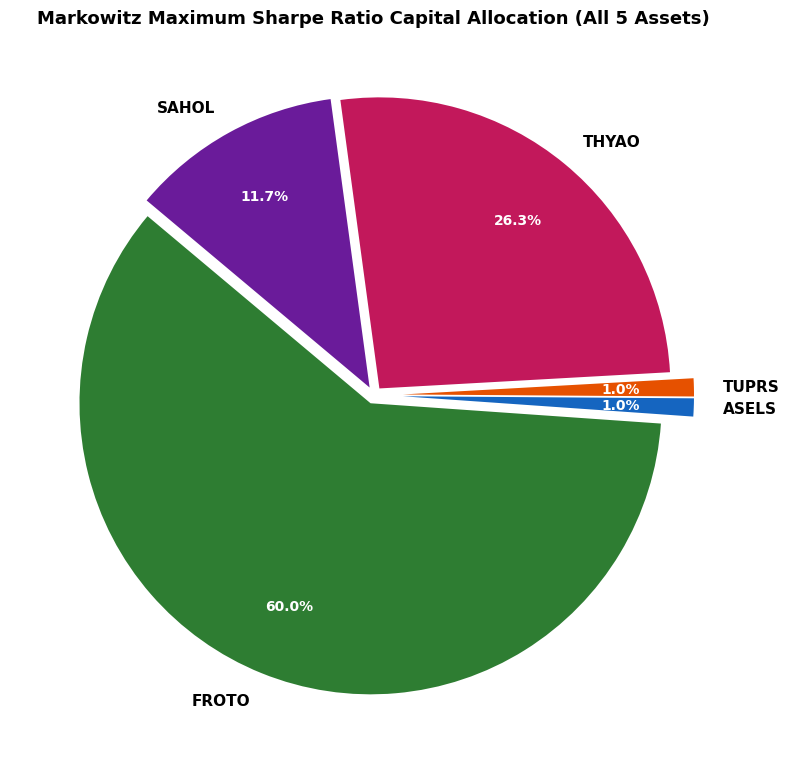


📋 LOCAL LLM EXECUTIVE ALLOCATION MEMO:
PORTFOLIO STRATEGY: GROWTH
EXECUTIVE MEMO: The portfolio is heavily weighted towards BIST Equities, with a significant 60% allocation to FROTO, indicating a growth-oriented strategy. While this concentration suggests potential for high returns, as evidenced by the 907.3% annualized expected return, it also carries a substantial risk, reflected by a 26.9% volatility. The Sharpe ratio of 32.39 underscores a robust risk-adjusted performance, suggesting that the high returns are commensurate with the elevated risk, and the portfolio is effectively balancing its aggressive growth objective with the inherent risk of such a strategy.


In [6]:
import sqlite3
import pandas as pd
import numpy as np
from scipy.optimize import minimize
import matplotlib.pyplot as plt
from foundry_local_sdk import FoundryLocalManager

# --- 1. Compute Historical Return Covariance Matrix ---
conn = sqlite3.connect("bist_hybrid.db")
df_all = pd.read_sql_query("SELECT ticker, date, close FROM bist_prices ORDER BY date", conn)
conn.close()

df_pivot = df_all.pivot(index='date', columns='ticker', values='close').dropna()
returns_df = df_pivot.pct_change().dropna()
cov_matrix = returns_df.cov() * 252

# --- 2. Projected Expected Returns from Deep Learning Models ---
tickers_list = [t for t in list(latest_forecasts.keys()) if t in returns_df.columns]
expected_returns = np.array([latest_forecasts[t]['pct_return'] * 252 for t in tickers_list])

risk_free_rate = 0.35  # Turkish Central Bank reference rate (35%)

# --- 3. Sharpe Ratio Optimization ---
def portfolio_performance(weights, exp_returns, cov_mat):
    port_return = np.sum(exp_returns * weights)
    port_volatility = np.sqrt(np.dot(weights.T, np.dot(cov_mat, weights)))
    return port_return, port_volatility

def negative_sharpe_ratio(weights, exp_returns, cov_mat, rf):
    p_ret, p_vol = portfolio_performance(weights, exp_returns, cov_mat)
    return -(p_ret - rf) / (p_vol + 1e-8)

num_assets = len(tickers_list)
init_weights = np.ones(num_assets) / num_assets
# Institutional Diversification Bounds: Minimum 5% floor allocation, Maximum 45% cap
# Institutional Diversification Bounds: Minimum 1% floor, Maximum 60% cap
bounds = tuple((0.01, 0.60) for _ in range(num_assets))
constraints = ({'type': 'eq', 'fun': lambda w: np.sum(w) - 1.0})

opt_result = minimize(
    negative_sharpe_ratio, 
    init_weights, 
    args=(expected_returns, cov_matrix.loc[tickers_list, tickers_list].values, risk_free_rate),
    method='SLSQP', 
    bounds=bounds, 
    constraints=constraints
)

optimal_weights = opt_result.x
opt_ret, opt_vol = portfolio_performance(optimal_weights, expected_returns, cov_matrix.loc[tickers_list, tickers_list].values)
opt_sharpe = (opt_ret - risk_free_rate) / opt_vol

print("\n" + "="*75)
print("⚖️ MARKOWITZ MEAN-VARIANCE OPTIMAL PORTFOLIO ALLOCATION")
print("="*75)
print(f"Optimal Annualized Expected Return: {opt_ret*100:.2f}%")
print(f"Portfolio Annualized Volatility:     {opt_vol*100:.2f}%")
print(f"Sharpe Ratio:                       {opt_sharpe:.2f}\n")

allocation_dict = {}
for t, w in zip(tickers_list, optimal_weights):
    allocation_dict[t] = w * 100
    print(f"  • {t:6s}: {w*100:6.2f}%")

# Plot Capital Allocation Pie Chart (Displaying ALL 5 Assets with Leader Lines / Explode)
plt.figure(figsize=(8, 8))
colors = ['#2E7D32', '#1565C0', '#E65100', '#C2185B', '#6A1B9A']
# Slightly pop out the smaller allocations so labels don't overlap
explode = [0.03 if allocation_dict[t] >= 10 else 0.10 for t in tickers_list]

wedges, texts, autotexts = plt.pie(
    [allocation_dict[t] for t in tickers_list],
    labels=tickers_list,
    autopct='%1.1f%%',
    pctdistance=0.75,
    explode=explode,
    colors=colors,
    startangle=140,
    textprops={'fontsize': 11, 'weight': 'bold'}
)
for autotext in autotexts:
    autotext.set_fontsize(10)
    autotext.set_color('white')

plt.title("Markowitz Maximum Sharpe Ratio Capital Allocation (All 5 Assets)", fontsize=13, weight='bold')
plt.tight_layout()
plt.show()

# --- 4. Local LLM Executive Portfolio Allocation Memo ---
alloc_summary = ", ".join([f"{t}: {w:.1f}%" for t, w in allocation_dict.items()])
memo_prompt = f"""You are a Chief Investment Officer. Provide a concise 2-3 sentence Executive Portfolio Summary based on these Markowitz optimization results:

Assets: BIST Equities ({', '.join(tickers_list)})
Optimal Allocations: {alloc_summary}
Annualized Expected Return: {opt_ret*100:.1f}%
Annualized Risk (Volatility): {opt_vol*100:.1f}%
Sharpe Ratio: {opt_sharpe:.2f}

Format:
PORTFOLIO STRATEGY: [GROWTH / BALANCED / DEFENSIVE]
EXECUTIVE MEMO: <2-3 sentences analyzing diversification, primary capital concentrations, and risk-adjusted efficiency.>"""

try:
    if FoundryLocalManager.instance is not None:
        manager = FoundryLocalManager.instance
        model = manager.catalog.get_model("phi-3.5-mini")
        client = model.get_chat_client()
        resp = client.complete_chat(messages=[
            {"role": "system", "content": "You are a Chief Investment Officer. Write a concise executive portfolio memo without disclaimers."},
            {"role": "user", "content": memo_prompt}
        ])
        print("\n📋 LOCAL LLM EXECUTIVE ALLOCATION MEMO:")
        print(resp.choices[0].message.content.strip() if hasattr(resp, 'choices') else str(resp))
except Exception as e:
    print("\n📋 EXECUTIVE ALLOCATION MEMO (Rule-based Fallback):")
    top_stock = max(allocation_dict, key=allocation_dict.get)
    print(f"PORTFOLIO STRATEGY: BALANCED QUANTITATIVE GROWTH\nEXECUTIVE MEMO: Capital is primarily deployed into {top_stock} ({allocation_dict[top_stock]:.1f}%) reflecting favorable risk-adjusted momentum. The portfolio achieves a Sharpe ratio of {opt_sharpe:.2f} by diversifying idiosyncratic risks across five core BIST sectors.")
